##<font color='Gold'> **GOOGLE COLAB & IMAGE SEGMENTATION**
</font>

## <font color='Green'> **[** **LANG SAM MODEL** **]** : Language based segmentation
</font>


In [ ]:
!pip -q install segment-geospatial groundingdino-py

from samgeo.text_sam import LangSAM
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os


[SEGMENT ANYTHING MODEL](https://segment-anything.com/)

## <font color='Green'> **[** **Upload image from laptop** **]**
</font>





Saving Screenshot 2026-01-17 162911.png to Screenshot 2026-01-17 162911.png


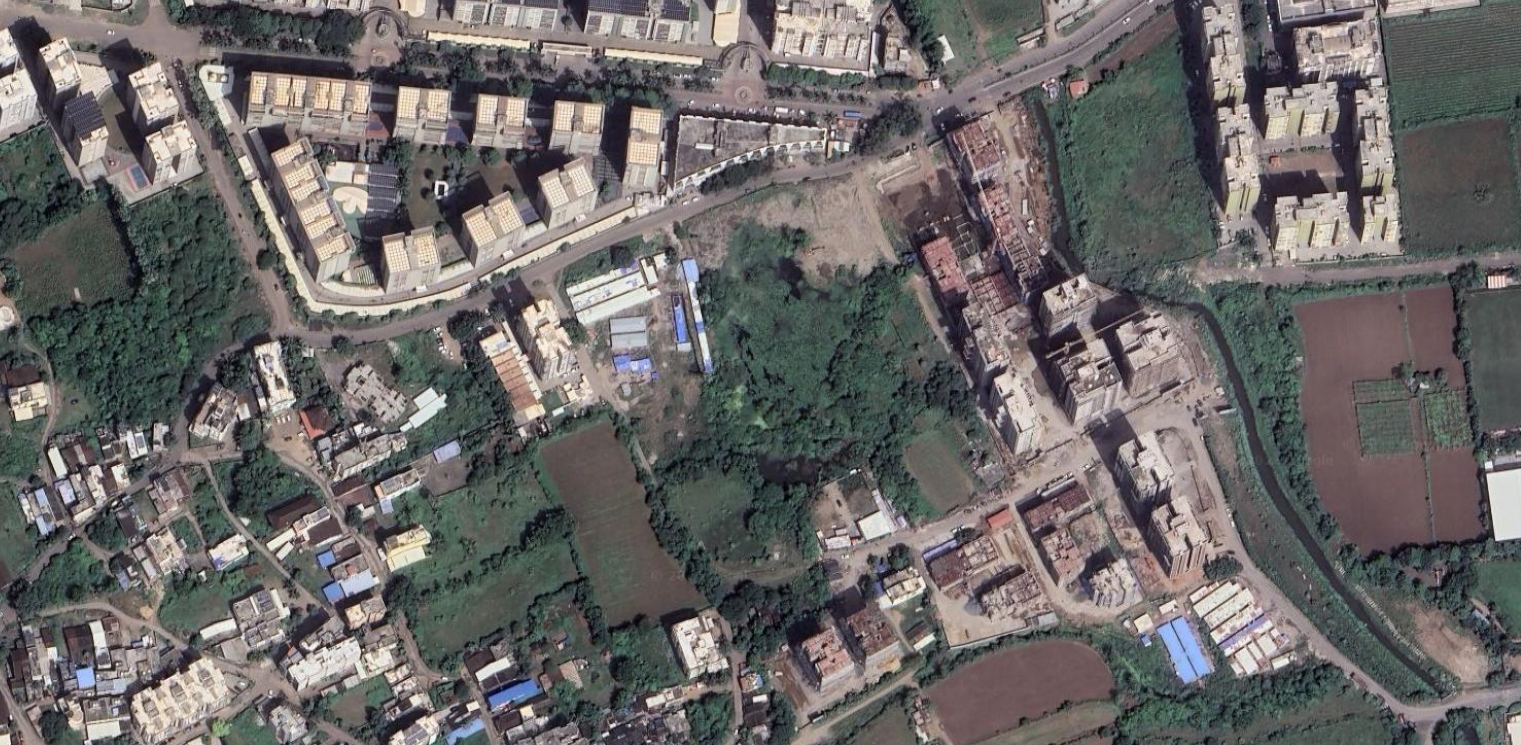

In [ ]:
from google.colab import files
uploaded = files.upload()   # choose image from laptop

img_path = list(uploaded.keys())[0]
image = Image.open(img_path).convert("RGB")
image

## <font color='Green'> **[** **Initialize LangSAM** **]**
</font>





In [ ]:
sam = LangSAM()

GroundingDINO_SwinB.cfg.py: 0.00B [00:00, ?B/s]

final text_encoder_type: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

groundingdino_swinb_cogcoor.pth:   0%|          | 0.00/938M [00:00<?, ?B/s]

Downloading: "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth" to /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth


100%|██████████| 2.39G/2.39G [00:17<00:00, 147MB/s]


## <font color='Green'> **[** **Segment using a text prompt** **]**
</font>





In [ ]:
text_prompt = "house"     # change this
box_th = 0.25
text_th = 0.25

sam.predict(
    image,
    text_prompt,
    box_threshold=box_th,
    text_threshold=text_th
)


## <font color='Green'> **[** **Output A — Visual overlay (boxes + masks)** **]**
</font>





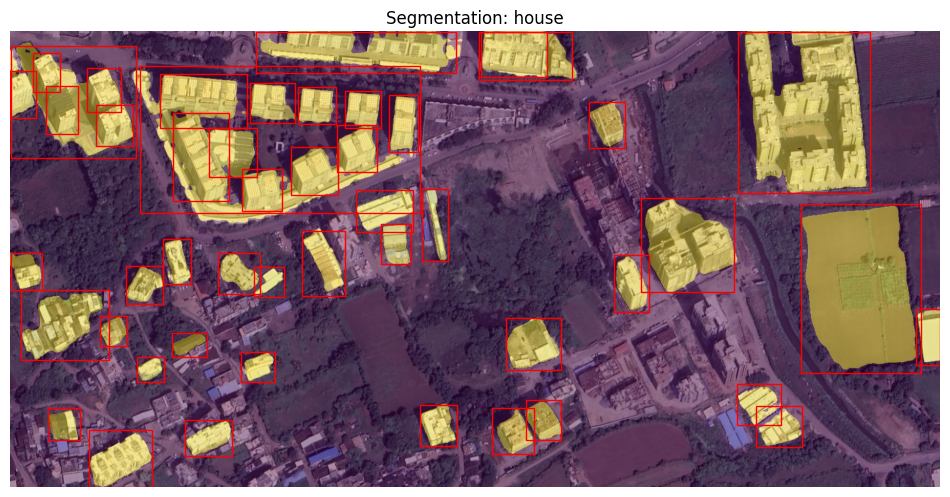

In [ ]:
sam.show_anns( title=f"Segmentation: {text_prompt}", blend=True )


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

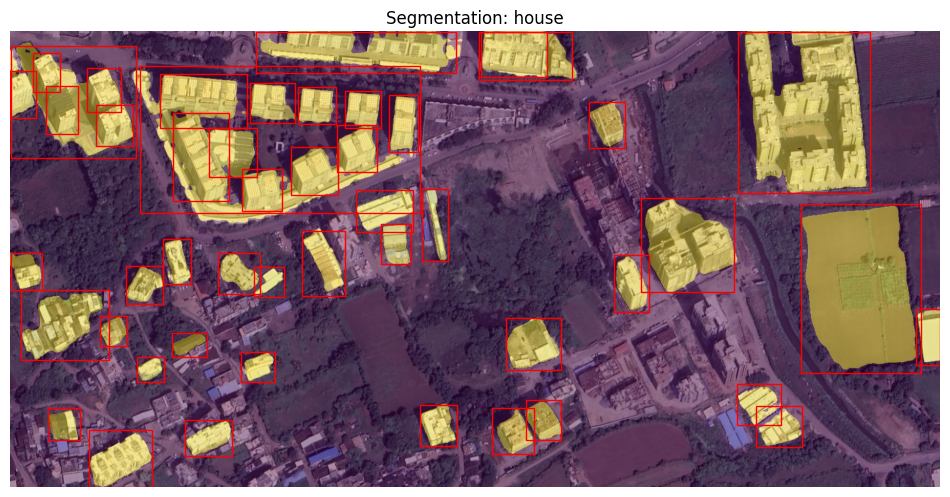

In [ ]:
# --- SAVE SEGMENTATION VISUAL AS PNG (DOWNLOADABLE) ---
import matplotlib.pyplot as plt
from google.colab import files

# Create the visualization
fig = plt.figure(figsize=(10, 10))
sam.show_anns(
    title=f"Segmentation: {text_prompt}",
    blend=True
)

# Save to file
out_file = "segmentation_output.png"
plt.savefig(out_file, bbox_inches="tight", dpi=200)
plt.close(fig)

# Download to laptop
files.download(out_file)
